In [3]:
# --- Imports ---
import numpy as np
import pandas as pd

# XGBoost and multi-output wrapper
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# --- Load dataset ---
data = pd.read_csv("../Data/OldSensorNodeData.csv", parse_dates=["Timestamp"])

print("Data loaded successfully!")
print(f"Dataset shape: {data.shape}")
print(data.head())

Data loaded successfully!
Dataset shape: (45728, 5)
            Timestamp    AQI  Temp  Hum  Pres
0 2025-12-07 23:51:11  65.32  21.4   73     0
1 2025-12-07 23:51:16  60.56  21.4   71     0
2 2025-12-07 23:51:21  57.26  21.4   71     0
3 2025-12-07 23:51:26  52.87  21.4   70     0
4 2025-12-07 23:51:31  50.79  21.4   69     0


In [ ]:
# --- IQR-based outlier capping ---
def cap_outliers_iqr(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

        print(f"{col}: capped to [{lower_bound:.2f}, {upper_bound:.2f}]")

    return df

# Apply outlier capping
data = cap_outliers_iqr(data, ['AQI', 'Temp', 'Hum'])

print("Outlier handling completed.")

In [6]:
# --- Time features ---
data['hour'] = data['Timestamp'].dt.hour
data['minute'] = data['Timestamp'].dt.minute
data['second'] = data['Timestamp'].dt.second

In [7]:
# --- Lag features ---
for col in ['AQI', 'Temp', 'Hum']:
    for lag in range(1, 4):  # previous 1, 2, 3 readings (5s, 10s, 15s)
        data[f'{col}_lag_{lag}'] = data[col].shift(lag)

In [8]:
# --- Rolling mean features ---
window_sizes = {
    '1min': 12,    # 12 × 5s = 1 minute
    '5min': 60,    # 5 minutes
    '15min': 180   # 15 minutes
}

for col in ['AQI', 'Temp', 'Hum']:
    for name, window in window_sizes.items():
        data[f'{col}_roll_mean_{name}'] = (
            data[col].rolling(window=window).mean()
        )


In [9]:
# --- Multi-step targets ---
for col in ['AQI', 'Temp', 'Hum']:
    data[f'{col}_1min'] = data[col].shift(-12)
    data[f'{col}_5min'] = data[col].shift(-60)
    data[f'{col}_15min'] = data[col].shift(-180)


In [10]:
data.dropna(inplace=True)
print("Lag, rolling features and targets ready!")
print(f"Dataset shape after processing: {data.shape}")


Lag, rolling features and targets ready!
Dataset shape after processing: (45369, 35)


In [11]:
# --- Feature columns ---
base_features = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']
lag_rolling_features = [c for c in data.columns if '_lag_' in c or 'roll_mean' in c]

feature_cols = base_features + lag_rolling_features

X = data[feature_cols]

# --- Target columns ---
target_cols = [
    c for c in data.columns
    if any(c.startswith(v) for v in ['AQI_', 'Temp_', 'Hum_'])
]

y = data[target_cols]

print(f"Number of features: {X.shape[1]}")
print(f"Number of targets: {y.shape[1]}")

Number of features: 25
Number of targets: 27


In [12]:
# %%
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train/Test split done.")


Train/Test split done.


In [13]:
xgb_base = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model = MultiOutputRegressor(xgb_base)


In [14]:
xgb_model.fit(X_train, y_train)

print("XGBoost training completed!")

XGBoost training completed!


In [16]:
# %%
y_pred = xgb_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [17]:
def evaluate_model(y_true, y_pred):
    metrics = pd.DataFrame(columns=['Target', 'MAE', 'RMSE', 'R2'])

    for i, target in enumerate(y_true.columns):
        y_t = y_true[target].values
        y_hat = y_pred[:, i]

        mae = mean_absolute_error(y_t, y_hat)
        rmse = np.sqrt(mean_squared_error(y_t, y_hat))
        r2 = r2_score(y_t, y_hat)

        metrics.loc[i] = [target, mae, rmse, r2]

    # --- Combined metrics ---
    metrics.loc[len(metrics)] = [
        'Combined',
        mean_absolute_error(y_true, y_pred, multioutput='uniform_average'),
        np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average')),
        r2_score(y_true, y_pred, multioutput='uniform_average')
    ]

    return metrics


In [18]:
xgb_metrics = evaluate_model(y_test, y_pred)
print(xgb_metrics)


                  Target        MAE       RMSE         R2
0              AQI_lag_1   1.395956   1.695060   0.873355
1              AQI_lag_2   1.607709   1.967439   0.829357
2              AQI_lag_3   1.654583   2.056221   0.813580
3             Temp_lag_1   0.014134   0.020638   0.998415
4             Temp_lag_2   0.021345   0.034949   0.995456
5             Temp_lag_3   0.003709   0.005862   0.999872
6              Hum_lag_1   0.027124   0.035031   0.998687
7              Hum_lag_2   0.070243   0.088859   0.991550
8              Hum_lag_3   0.004869   0.060272   0.996113
9     AQI_roll_mean_1min   1.506194   1.807387   0.855105
10    AQI_roll_mean_5min   2.042619   2.455492   0.727832
11   AQI_roll_mean_15min   4.120920   5.182063  -0.291009
12   Temp_roll_mean_1min   0.027432   0.034864   0.995336
13   Temp_roll_mean_5min   0.019426   0.027378   0.997134
14  Temp_roll_mean_15min   0.025080   0.034896   0.995407
15    Hum_roll_mean_1min   0.055419   0.091000   0.982767
16    Hum_roll

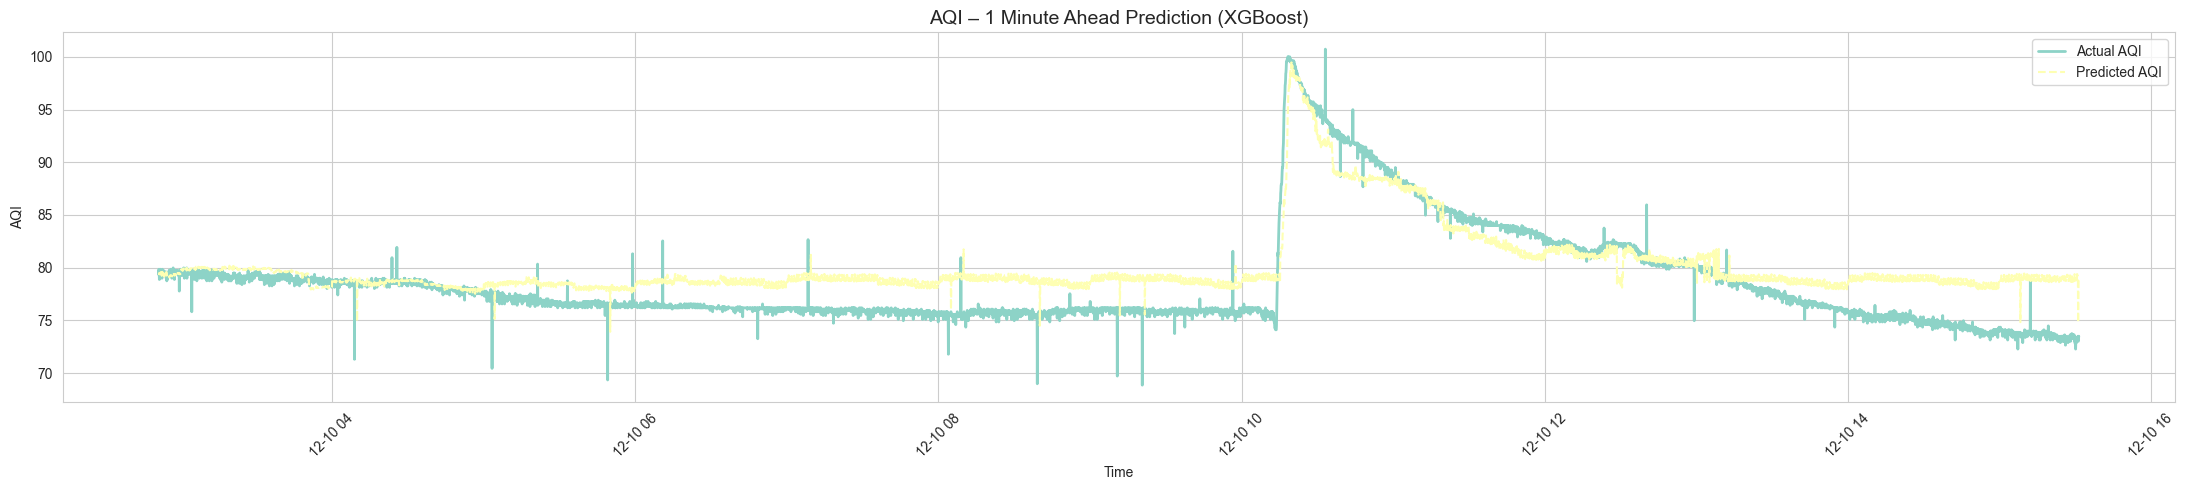

In [19]:
# %%
plot_df = pd.DataFrame({
    'Timestamp': data['Timestamp'].iloc[split_idx:split_idx + len(y_pred)],
    'Actual': y_test['AQI_1min'].values,
    'Predicted': y_pred[:, y_test.columns.get_loc('AQI_1min')]
})

sns.set_style("whitegrid")
plt.figure(figsize=(22, 5))

sns.lineplot(
    data=plot_df,
    x='Timestamp',
    y='Actual',
    label='Actual AQI',
    linewidth=2
)

sns.lineplot(
    data=plot_df,
    x='Timestamp',
    y='Predicted',
    label='Predicted AQI',
    linestyle='--'
)

plt.title('AQI – 1 Minute Ahead Prediction (XGBoost)', fontsize=14)
plt.xlabel('Time')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


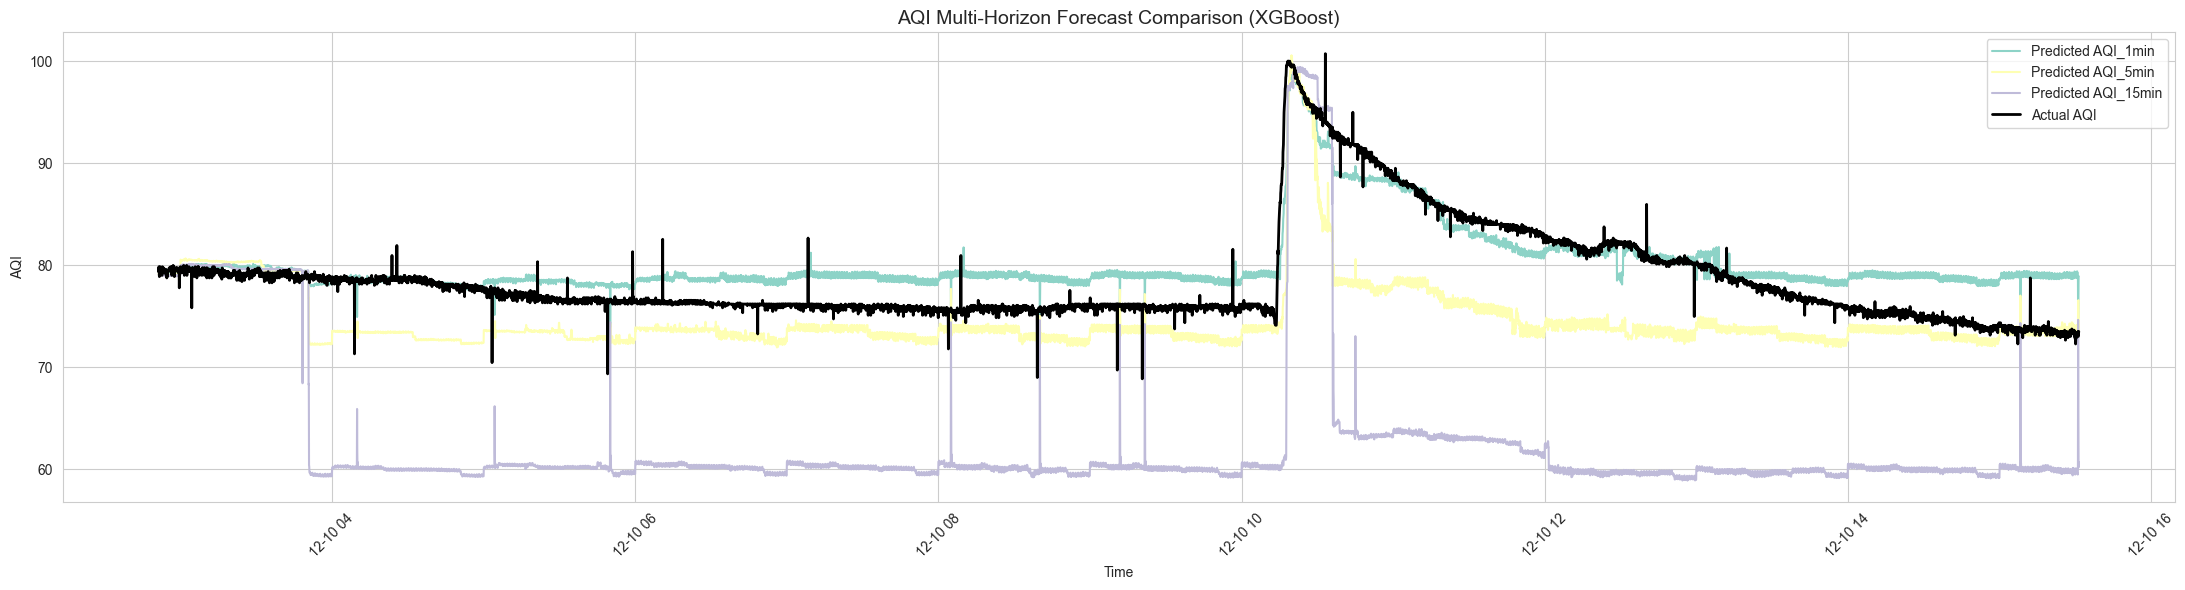

In [20]:
# %%
horizons = ['AQI_1min', 'AQI_5min', 'AQI_15min']
plt.figure(figsize=(22, 6))

for h in horizons:
    idx = y_test.columns.get_loc(h)
    sns.lineplot(
        x=plot_df['Timestamp'],
        y=y_pred[:, idx],
        label=f'Predicted {h}'
    )

sns.lineplot(
    x=plot_df['Timestamp'],
    y=y_test['AQI_1min'],
    label='Actual AQI',
    linewidth=2,
    color='black'
)

plt.title('AQI Multi-Horizon Forecast Comparison (XGBoost)', fontsize=14)
plt.xlabel('Time')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


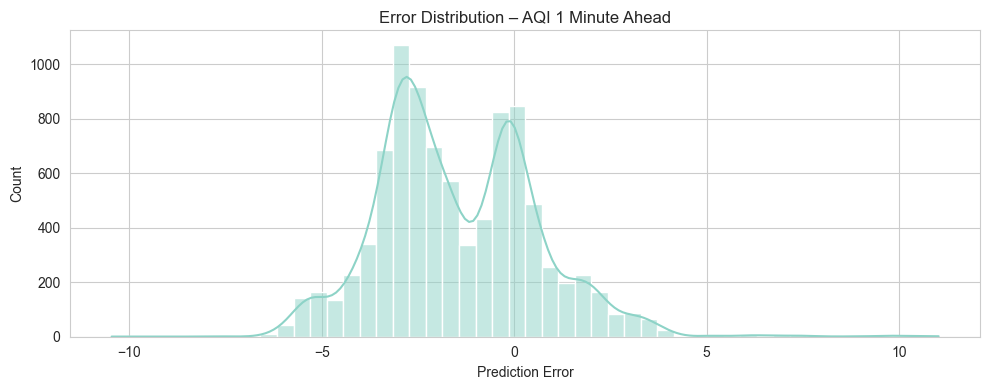

In [21]:
errors = y_test['AQI_1min'].values - y_pred[:, y_test.columns.get_loc('AQI_1min')]

plt.figure(figsize=(10, 4))
sns.histplot(errors, bins=50, kde=True)
plt.title('Error Distribution – AQI 1 Minute Ahead')
plt.xlabel('Prediction Error')
plt.tight_layout()
plt.show()
